# `dataloom` — full-experiment analysis notebook

Builds every figure and table required by `docs/experiments.md` §4.7-§9.8
(Experiments 1, 2, 3, 4, A, B) plus the §12-§13 master plots/tables.

Outputs are persisted to each run's `figures/` and `aggregated/` directory
as `.pdf` + `.png` per §17.

Anywhere empirical results diverge from theory predictions, the cell is
annotated **explicitly** — not smoothed. See §16.


In [1]:
%run __dev_setup.py


🔁 Autoreload is ON (IPython detected).
✅ Using dataloom from: /Users/iamsikun/research/dataloom/src/dataloom


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from dataloom.notation import classify_regime, theory_slope
from dataloom.oracle import (
    B_eff, V_real, R_profile, foc_residual, safe_condition,
    oracle_grid, m_of_n, v_of_n,
)
from dataloom.io.results import read_run

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['savefig.bbox'] = 'tight'


## 0. Discover run directories

Pick the most recent run directory for each experiment. If a fresh full
run is desired, re-run the corresponding `scripts/run_experiment.py`
config first.


In [3]:
RESULTS = Path('../results').resolve()

def latest_run(prefix: str) -> Path:
    candidates = [p for p in RESULTS.glob(f'{prefix}*') if p.is_dir()]
    if not candidates:
        raise FileNotFoundError(f'no run dir under results/ matching {prefix!r}')
    return max(candidates, key=lambda p: p.stat().st_mtime)

RUN_EXP1 = latest_run('exp1_phase_diagram')
RUN_EXP2 = latest_run('exp2_adaptive')
RUN_EXP3 = latest_run('exp3_multichannel')
RUN_EXP4 = latest_run('exp4_inference')
RUN_EXPA = latest_run('expA_tabular')
RUN_EXPB = latest_run('expB_causal')

for label, p in [('exp1', RUN_EXP1), ('exp2', RUN_EXP2),
                  ('exp3', RUN_EXP3), ('exp4', RUN_EXP4),
                  ('expA', RUN_EXPA), ('expB', RUN_EXPB)]:
    n_parts = sum(1 for _ in (p / 'raw').glob('cell=*/part-*.parquet'))
    print(f'{label}: {p.name}  ({n_parts} parquet parts)')


exp1: exp1_phase_diagram__c0dc1ac__20260503T074341__dirty  (336 parquet parts)
exp2: exp2_adaptive__c0dc1ac__20260503T075038__dirty  (90 parquet parts)
exp3: exp3_multichannel__c0dc1ac__20260503T075130__dirty  (6 parquet parts)
exp4: exp4_inference__c0dc1ac__20260503T075132__dirty  (6 parquet parts)
expA: expA_tabular__c0dc1ac__20260503T075135__dirty  (6 parquet parts)
expB: expB_causal__c0dc1ac__20260503T075151__dirty  (6 parquet parts)


In [4]:
def save_fig(fig, run_dir: Path, stem: str) -> None:
    out_dir = run_dir / 'figures'
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f'{stem}.pdf', bbox_inches='tight')
    fig.savefig(out_dir / f'{stem}.png', dpi=150, bbox_inches='tight')
    print(f'wrote {out_dir / stem}.pdf + .png')


## 1. Experiment 1 — phase diagram validation (§4)

Estimators:
`real_only_all`, `synthetic_only_full_calibration`, `naive_pooling`,
`fixed_half_split_oracle_alpha`, `old_fixed_share_oracle_alpha`,
`corrected_oracle_gn`, `safe_corrected_oracle_gn`.


In [5]:
raw1 = read_run(RUN_EXP1 / 'raw')
table_s1 = pd.read_parquet(RUN_EXP1 / 'aggregated' / 'table_s1_scaling.parquet')
table_s2 = pd.read_parquet(RUN_EXP1 / 'aggregated' / 'table_s2_estimator_perf.parquet')
print(f'rows: {len(raw1):,}; table_s1 shape {table_s1.shape}; table_s2 shape {table_s2.shape}')
table_s1


rows: 9,996,000; table_s1 shape (42, 10); table_s2 shape (2352, 14)


,beta,rho,empirical_slope,slope_se,n_points,n_dropped_boundary,theory_regime,theory_slope,mean_oracle_lambda_at_largest_n,boundary_selected_rate
0,0.25,0.0,NaN,NaN,0,8,persistent_variance,0.000000,0.0,1.0
1,0.25,0.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0
2,0.25,1.0,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0
3,0.25,1.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0
4,0.25,2.0,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0
5,0.25,3.0,NaN,NaN,1,7,slow_learning,0.000000,0.00005,0.875
6,0.40,0.0,NaN,NaN,0,8,persistent_variance,0.000000,0.0,1.0
7,0.40,0.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0
8,0.40,1.0,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0
9,0.40,1.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0


### Figure S1 — Allocation phase diagram (§4.7)

Heatmap colored by theoretical regime per (β, ρ). Markers indicate which
(β, ρ) cells were actually simulated.


wrote /Users/iamsikun/research/dataloom/results/exp1_phase_diagram__c0dc1ac__20260503T074341__dirty/figures/figure_s1_phase_diagram.pdf + .png


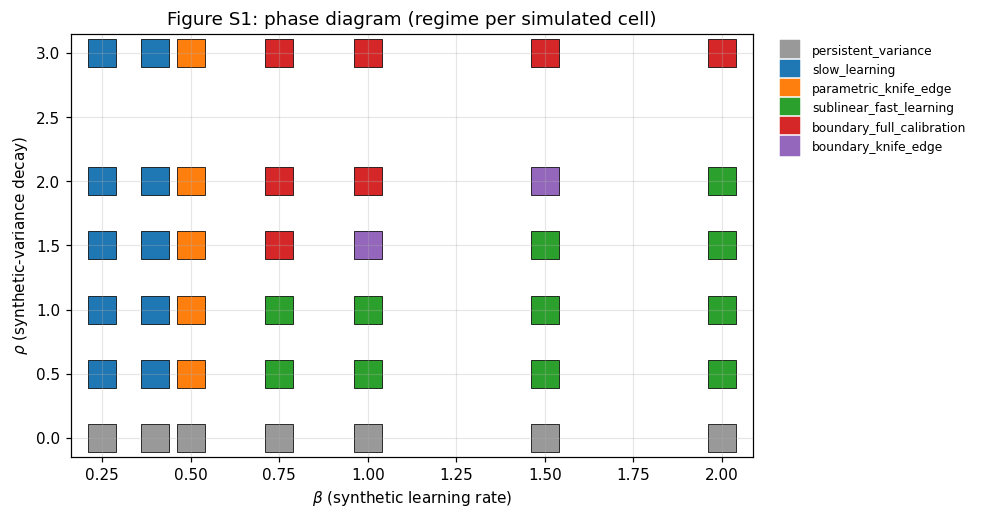

In [6]:
betas = sorted(raw1['beta'].unique())
rhos = sorted(raw1['rho'].unique())
REGIME_COLORS = {
    'persistent_variance':       '#999999',
    'slow_learning':             '#1f77b4',
    'parametric_knife_edge':     '#ff7f0e',
    'sublinear_fast_learning':   '#2ca02c',
    'boundary_full_calibration': '#d62728',
    'boundary_knife_edge':       '#9467bd',
}
fig, ax = plt.subplots(figsize=(8, 5))
for b in betas:
    for r in rhos:
        regime = classify_regime(b, r)
        ax.scatter(b, r, s=320, c=REGIME_COLORS[regime],
                   marker='s', edgecolor='black', linewidth=0.5)
handles = [plt.Line2D([0],[0], marker='s', color='w',
                       markerfacecolor=c, markersize=14, label=k)
           for k, c in REGIME_COLORS.items()]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, frameon=False)
ax.set_xlabel(r'$\beta$ (synthetic learning rate)')
ax.set_ylabel(r'$\rho$ (synthetic-variance decay)')
ax.set_title('Figure S1: phase diagram (regime per simulated cell)')
ax.grid(True, alpha=0.3)
save_fig(fig, RUN_EXP1, 'figure_s1_phase_diagram')
plt.show()


### Figure S2 — Calibration size scaling (§4.7)

Recommended panels per spec: (β=1, ρ=0), (β=0.4, ρ=1), (β=1, ρ=1),
(β=1, ρ=2). Theoretical slope overlaid.


wrote /Users/iamsikun/research/dataloom/results/exp1_phase_diagram__c0dc1ac__20260503T074341__dirty/figures/figure_s2_calibration_scaling.pdf + .png


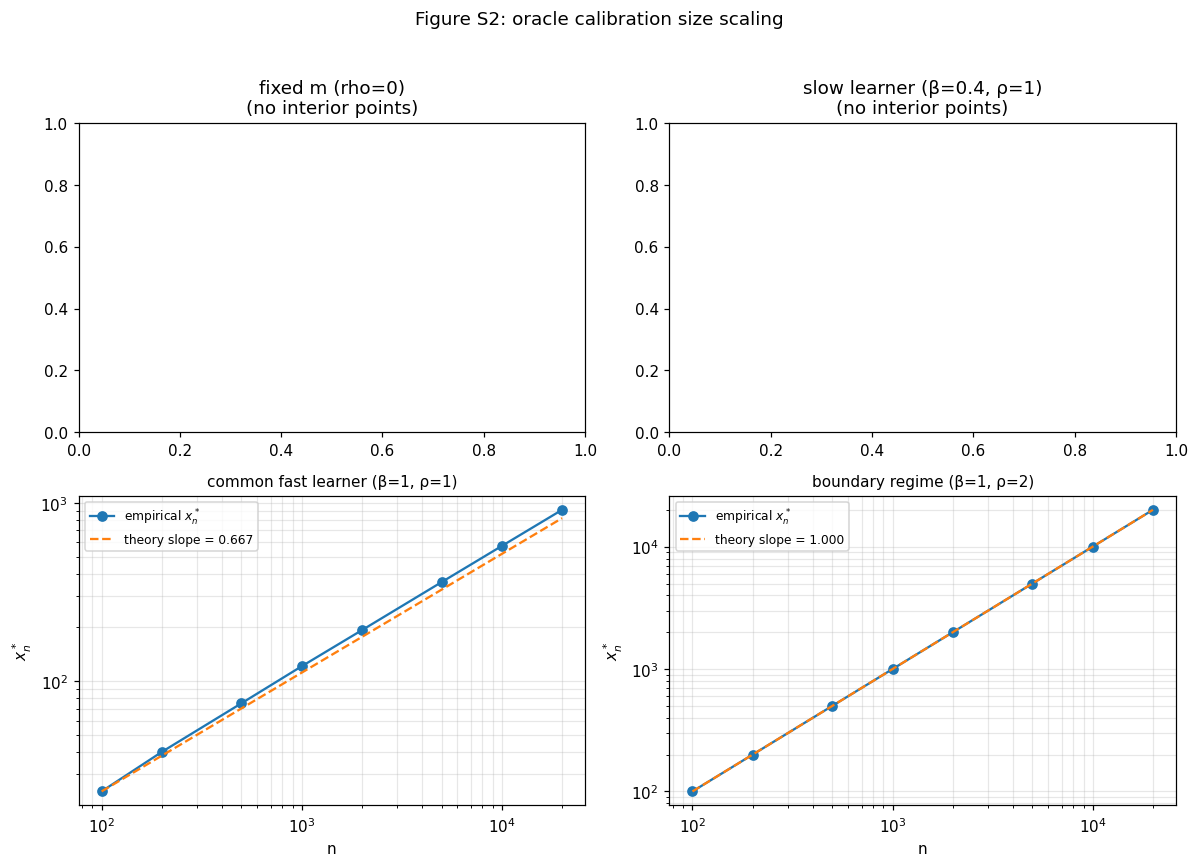

In [7]:
cell_oracle = (raw1.groupby(['beta', 'rho', 'n'], observed=True)['oracle_x']
                  .first().reset_index())
panels = [
    (1.0, 0.0, 'fixed m (rho=0)'),
    (0.4, 1.0, 'slow learner (β=0.4, ρ=1)'),
    (1.0, 1.0, 'common fast learner (β=1, ρ=1)'),
    (1.0, 2.0, 'boundary regime (β=1, ρ=2)'),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (b, r, title) in zip(axes.flat, panels):
    sub = cell_oracle[(cell_oracle['beta']==b) & (cell_oracle['rho']==r)]
    sub = sub[sub['oracle_x'] > 0].sort_values('n')
    if sub.empty:
        ax.set_title(f'{title}\n(no interior points)')
        continue
    ax.loglog(sub['n'], sub['oracle_x'], 'o-', label=r'empirical $x_n^*$')
    sl = theory_slope(b, r)
    if sl is not None and sl > 0:
        n_arr = np.array(sub['n'])
        ref = sub['oracle_x'].iloc[0] / (n_arr[0] ** sl)
        ax.loglog(n_arr, ref * n_arr ** sl, '--',
                  label=f'theory slope = {sl:.3f}')
    ax.set_xlabel('n')
    ax.set_ylabel(r'$x_n^*$')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)
fig.suptitle('Figure S2: oracle calibration size scaling')
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_fig(fig, RUN_EXP1, 'figure_s2_calibration_scaling')
plt.show()


#### Table S1 — predicted vs empirical scaling (§4.8)

Annotated `(disagrees with theory)` if the empirical slope is outside
theory ± 3·SE for any cell with a defined theoretical slope.


In [8]:
ts1 = table_s1.copy()
def annotate(row):
    if row['theory_slope'] is None or np.isnan(row['theory_slope']):
        return ''
    if np.isnan(row['empirical_slope']):
        return ''
    diff = abs(row['empirical_slope'] - row['theory_slope'])
    se = row['slope_se'] if pd.notna(row['slope_se']) else 0.0
    return '(disagrees with theory)' if diff > 3 * se else ''
ts1['flag'] = ts1.apply(annotate, axis=1)
ts1


,beta,rho,empirical_slope,slope_se,n_points,n_dropped_boundary,theory_regime,theory_slope,mean_oracle_lambda_at_largest_n,boundary_selected_rate,flag
0,0.25,0.0,NaN,NaN,0,8,persistent_variance,0.000000,0.0,1.0,
1,0.25,0.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0,
2,0.25,1.0,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0,
3,0.25,1.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0,
4,0.25,2.0,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0,
5,0.25,3.0,NaN,NaN,1,7,slow_learning,0.000000,0.00005,0.875,
6,0.40,0.0,NaN,NaN,0,8,persistent_variance,0.000000,0.0,1.0,
7,0.40,0.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0,
8,0.40,1.0,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0,
9,0.40,1.5,NaN,NaN,0,8,slow_learning,0.000000,0.0,1.0,


### Figure S3 — Calibration share λ vs n (§4.7)

In the common (β>0.5, ρ=1) regime we expect x* ↑ but λ* = x*/n ↓.


wrote /Users/iamsikun/research/dataloom/results/exp1_phase_diagram__c0dc1ac__20260503T074341__dirty/figures/figure_s3_calibration_share.pdf + .png


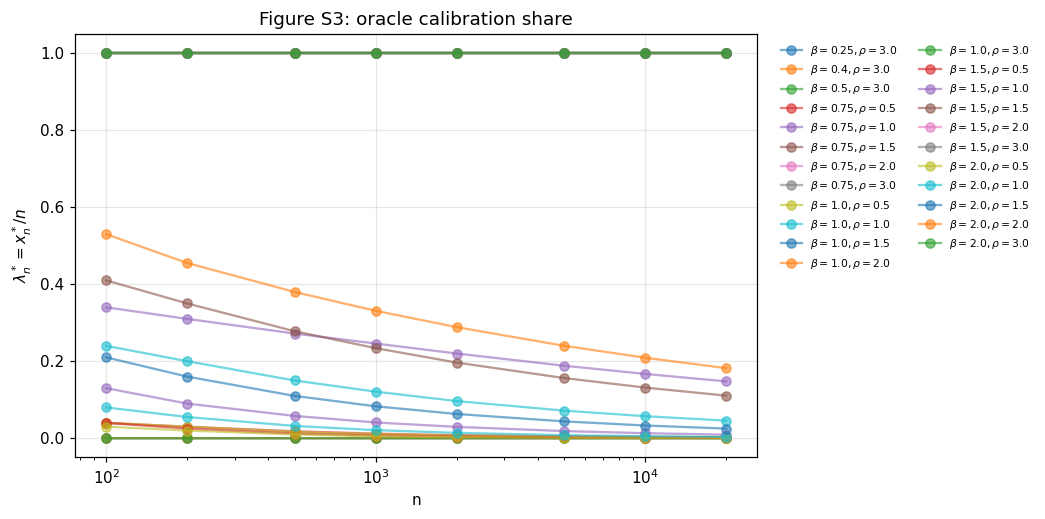

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for (b, r), sub in cell_oracle.groupby(['beta', 'rho'], observed=True):
    if sub['oracle_x'].max() == 0:
        continue
    sub = sub.sort_values('n')
    lam = sub['oracle_x'] / sub['n']
    ax.semilogx(sub['n'], lam, 'o-', alpha=0.6, label=fr'$\beta={b}, \rho={r}$')
ax.set_xlabel('n')
ax.set_ylabel(r'$\lambda_n^* = x_n^* / n$')
ax.set_title('Figure S3: oracle calibration share')
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=False)
ax.grid(True, alpha=0.3)
save_fig(fig, RUN_EXP1, 'figure_s3_calibration_share')
plt.show()


### Figure S4 — MSE ratio by estimator (§4.7)

MSE / MSE(real_only_all) for all estimators across n, faceted by (β, ρ).


wrote /Users/iamsikun/research/dataloom/results/exp1_phase_diagram__c0dc1ac__20260503T074341__dirty/figures/figure_s4_mse_ratio.pdf + .png


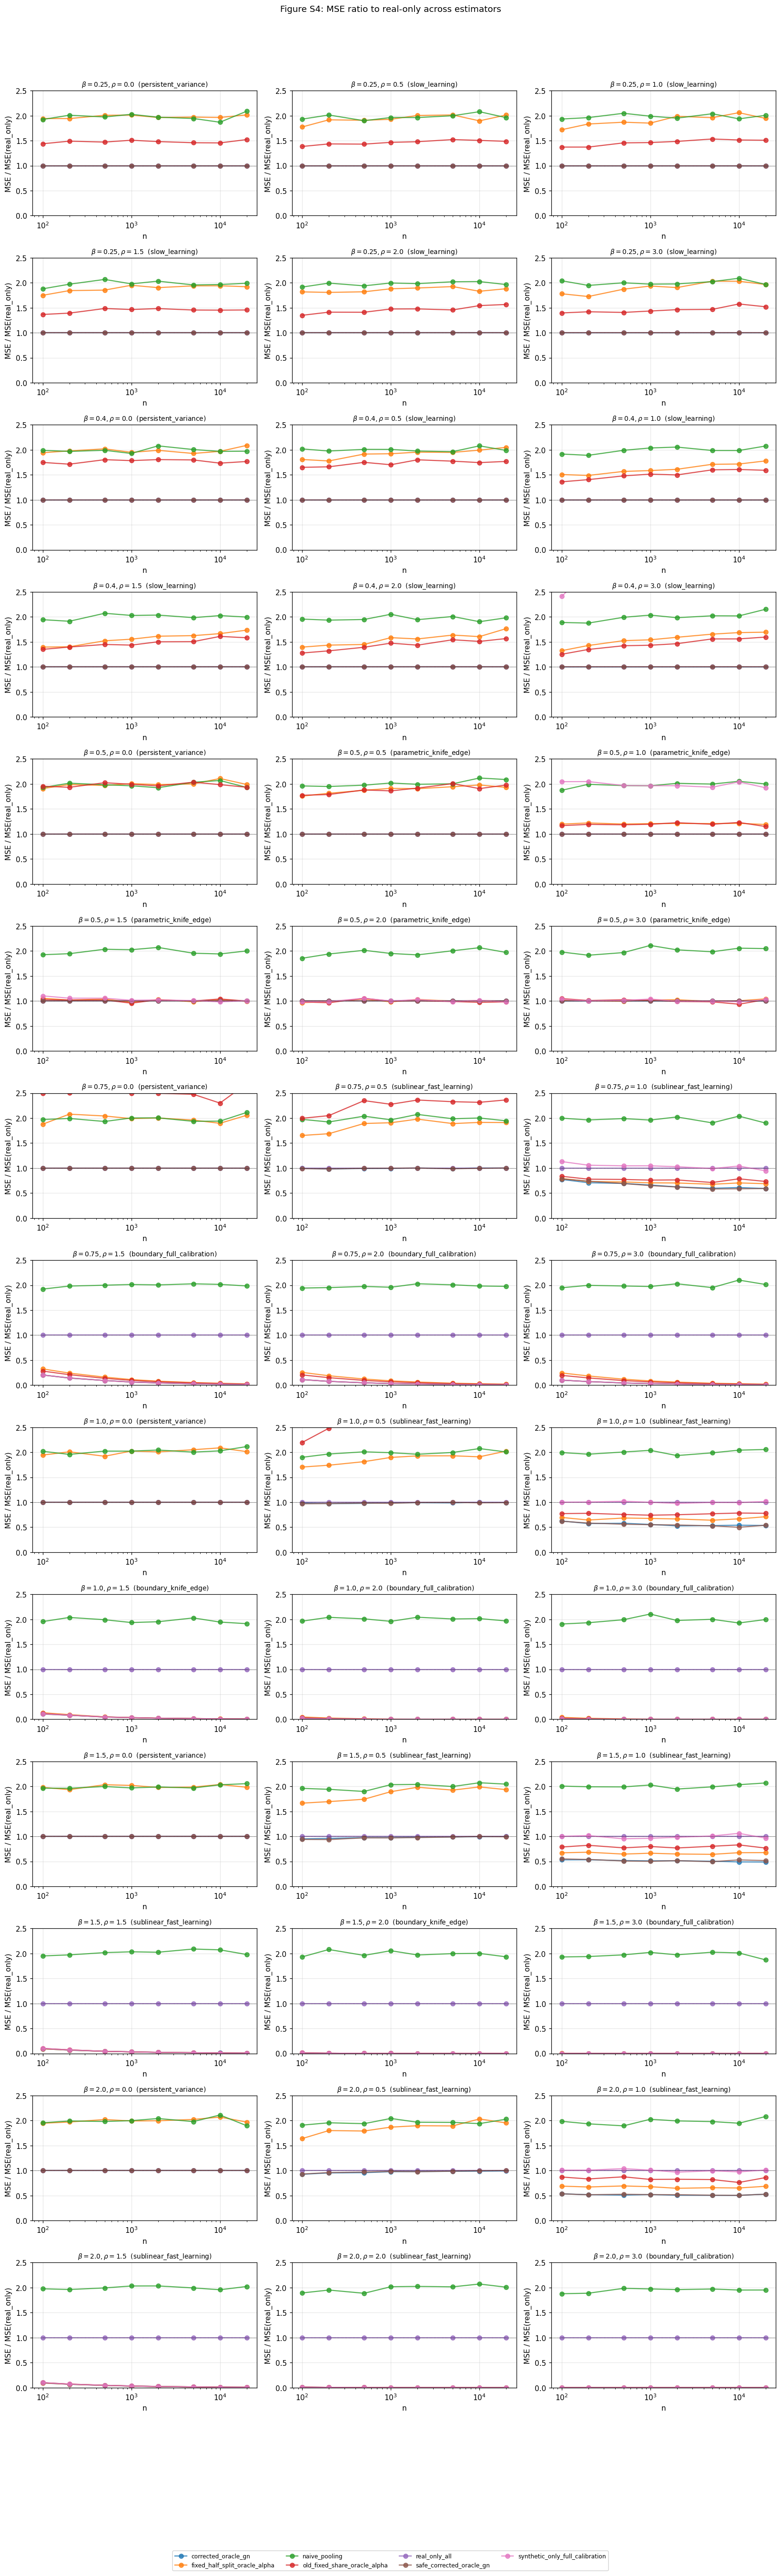

In [10]:
pairs = sorted(set(zip(table_s2['beta'], table_s2['rho'])))
cols = 3
rows = (len(pairs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.5*rows), squeeze=False)
for ax, (b, r) in zip(axes.flat, pairs):
    sub = table_s2[(table_s2['beta']==b) & (table_s2['rho']==r)]
    for est, eg in sub.groupby('estimator', observed=True):
        eg = eg.sort_values('n')
        ax.semilogx(eg['n'], eg['mse_ratio_to_real'], 'o-', label=est, alpha=0.8)
    ax.axhline(1.0, color='black', linestyle=':', linewidth=0.7)
    ax.set_title(fr'$\beta={b}, \rho={r}$  ({classify_regime(b, r)})', fontsize=9)
    ax.set_xlabel('n')
    ax.set_ylabel('MSE / MSE(real_only)')
    ax.set_ylim(0, 2.5)
    ax.grid(True, alpha=0.3)
for ax in axes.flat[len(pairs):]:
    ax.axis('off')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Figure S4: MSE ratio to real-only across estimators')
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
save_fig(fig, RUN_EXP1, 'figure_s4_mse_ratio')
plt.show()


#### Table S2 — Estimator performance (§4.8)

Headline regime (β=1, ρ=1) shown inline. Full table on disk.


In [11]:
headline = (table_s2[(table_s2['beta']==1.0) & (table_s2['rho']==1.0)]
                .sort_values(['n', 'mse_ratio_to_real']))
headline[['n','estimator','mse','mse_ratio_to_real','oracle_regret','x_selected']]


,n,estimator,mse,mse_ratio_to_real,oracle_regret,x_selected
1461,100,safe_corrected_oracle_gn,0.006093,0.620567,-0.005741,24.0
1456,100,corrected_oracle_gn,0.006128,0.62415,0.0,24.0
1457,100,fixed_half_split_oracle_alpha,0.006835,0.696102,0.115279,50.0
1459,100,old_fixed_share_oracle_alpha,0.007582,0.77223,0.237251,66.0
1460,100,real_only_all,0.009819,1.0,0.602178,0.0
1462,100,synthetic_only_full_calibration,0.009824,1.000537,0.603039,100.0
1458,100,naive_pooling,0.01958,1.994187,2.195044,50.0
1463,200,corrected_oracle_gn,0.002878,0.574265,0.0,40.0
1468,200,safe_corrected_oracle_gn,0.002925,0.583544,0.016158,40.0
1464,200,fixed_half_split_oracle_alpha,0.003229,0.644237,0.121846,100.0


## 2. Experiment 2 — adaptive estimator (§5)


In [12]:
raw2 = read_run(RUN_EXP2 / 'raw')
agg2_dir = RUN_EXP2 / 'aggregated'
table_a1 = pd.read_parquet(agg2_dir / 'table_a1_learning_curve.parquet') \
    if (agg2_dir / 'table_a1_learning_curve.parquet').exists() else pd.DataFrame()
table_a2 = pd.read_parquet(agg2_dir / 'table_a2_adaptive_perf.parquet')
print(f'rows: {len(raw2):,}; table_a1 shape {table_a1.shape}; table_a2 shape {table_a2.shape}')


rows: 1,155,000; table_a1 shape (360, 11); table_a2 shape (630, 14)


### Figure A1 — Estimated learning curves

log b̂²(x_j) vs log x_j with the fitted line of slope −2β̂. We plot the
average β̂ and ĉ across replications at the largest n in each (β, ρ) pair.


wrote /Users/iamsikun/research/dataloom/results/exp2_adaptive__c0dc1ac__20260503T075038__dirty/figures/figure_a1_learning_curves.pdf + .png


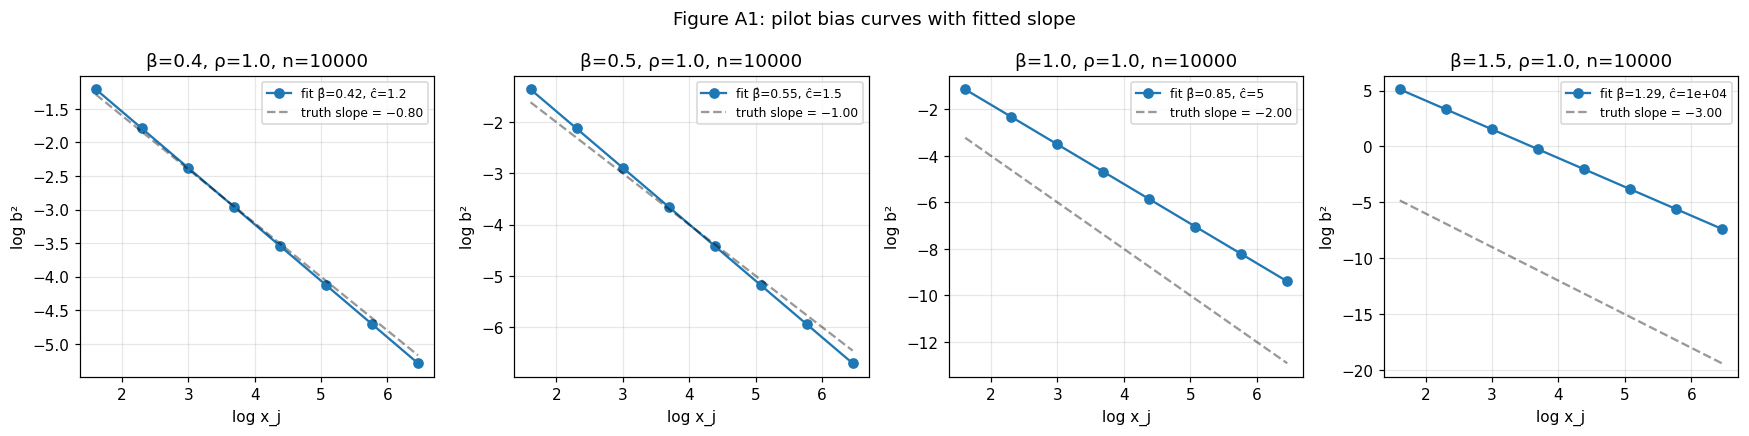

In [13]:
from dataloom.adaptive.bias_curve import default_pilot_grid

# We don't store per-replication pilot bias curves in raw output; instead show
# the mean β̂ and ĉ envelopes at the largest n.
cells_to_plot = [(0.4, 1.0), (0.5, 1.0), (1.0, 1.0), (1.5, 1.0)]
fig, axes = plt.subplots(1, len(cells_to_plot), figsize=(4*len(cells_to_plot), 4),
                          squeeze=False)
for ax, (b, r) in zip(axes.flat, cells_to_plot):
    sub = table_a1[(table_a1['beta']==b) & (table_a1['rho']==r) &
                    (table_a1['method']=='corrected_adaptive_gn')] \
          if not table_a1.empty else pd.DataFrame()
    if sub.empty:
        ax.set_title(f'β={b}, ρ={r}\n(no data)')
        continue
    n_max = int(sub['n'].max())
    grid = default_pilot_grid(n_max).astype(float)
    s = sub[sub['n']==n_max].iloc[0]
    beta_hat = s['mean_beta_hat']; c_hat = s['mean_c_hat']
    log_b2 = np.log(c_hat) - 2 * beta_hat * np.log(grid)
    ax.plot(np.log(grid), log_b2, 'o-', label=f'fit β̂={beta_hat:.2f}, ĉ={c_hat:.2g}')
    # truth reference
    log_b2_true = np.log(1.0) - 2 * b * np.log(grid)
    ax.plot(np.log(grid), log_b2_true, 'k--', alpha=0.4,
            label=f'truth slope = −{2*b:.2f}')
    ax.set_xlabel('log x_j')
    ax.set_ylabel('log b²')
    ax.set_title(f'β={b}, ρ={r}, n={n_max}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle('Figure A1: pilot bias curves with fitted slope')
fig.tight_layout()
save_fig(fig, RUN_EXP2, 'figure_a1_learning_curves')
plt.show()


### Figure A2 — Adaptive vs oracle allocation

Per-replication scatter of x̂ (corrected_adaptive_gn) vs oracle x*.


wrote /Users/iamsikun/research/dataloom/results/exp2_adaptive__c0dc1ac__20260503T075038__dirty/figures/figure_a2_adaptive_vs_oracle.pdf + .png


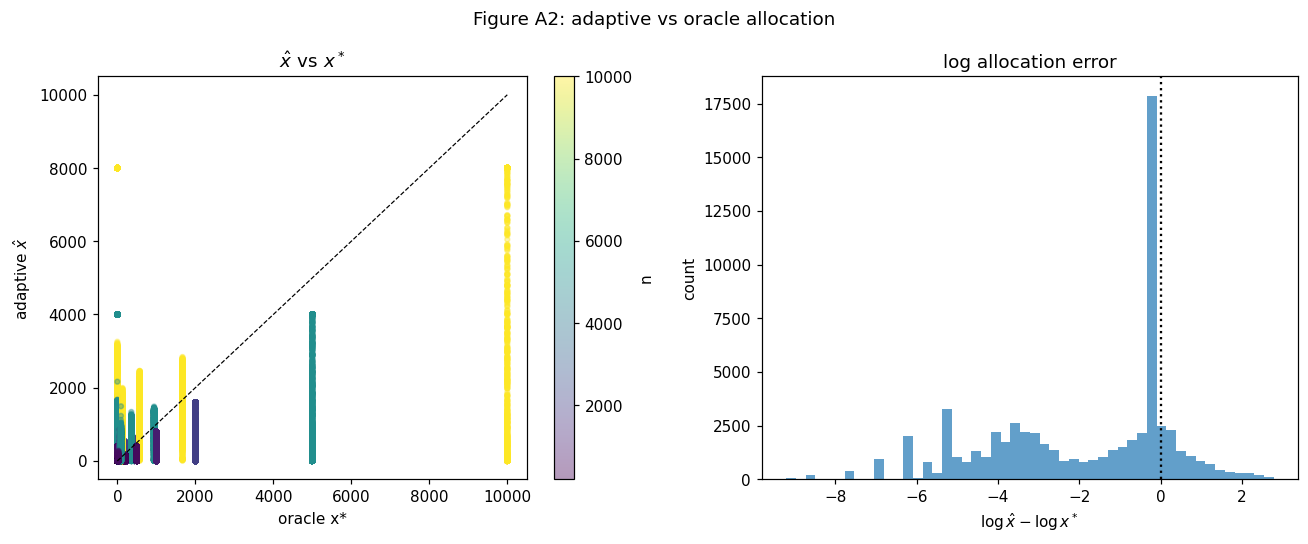

In [14]:
sub = raw2[(raw2['method']=='corrected_adaptive_gn') &
            raw2['x_selected'].notna()]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
sc = ax.scatter(sub['oracle_x'], sub['x_selected'], c=sub['n'], cmap='viridis',
                alpha=0.4, s=10)
lim = max(sub['oracle_x'].max(), sub['x_selected'].max())
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8)
ax.set_xlabel('oracle x*')
ax.set_ylabel(r'adaptive $\hat x$')
ax.set_title(r'$\hat x$ vs $x^*$')
plt.colorbar(sc, ax=ax, label='n')

ax = axes[1]
ok = (sub['oracle_x'] > 0) & (sub['x_selected'] > 0)
ax.hist(np.log(sub.loc[ok, 'x_selected'].astype(float)) -
         np.log(sub.loc[ok, 'oracle_x'].astype(float)),
         bins=50, alpha=0.7)
ax.axvline(0, color='black', linestyle=':')
ax.set_xlabel(r'$\log\hat x - \log x^*$')
ax.set_ylabel('count')
ax.set_title(r'log allocation error')
fig.suptitle('Figure A2: adaptive vs oracle allocation')
fig.tight_layout()
save_fig(fig, RUN_EXP2, 'figure_a2_adaptive_vs_oracle')
plt.show()


### Figure A3 — Adaptive regret vs n


wrote /Users/iamsikun/research/dataloom/results/exp2_adaptive__c0dc1ac__20260503T075038__dirty/figures/figure_a3_adaptive_regret.pdf + .png


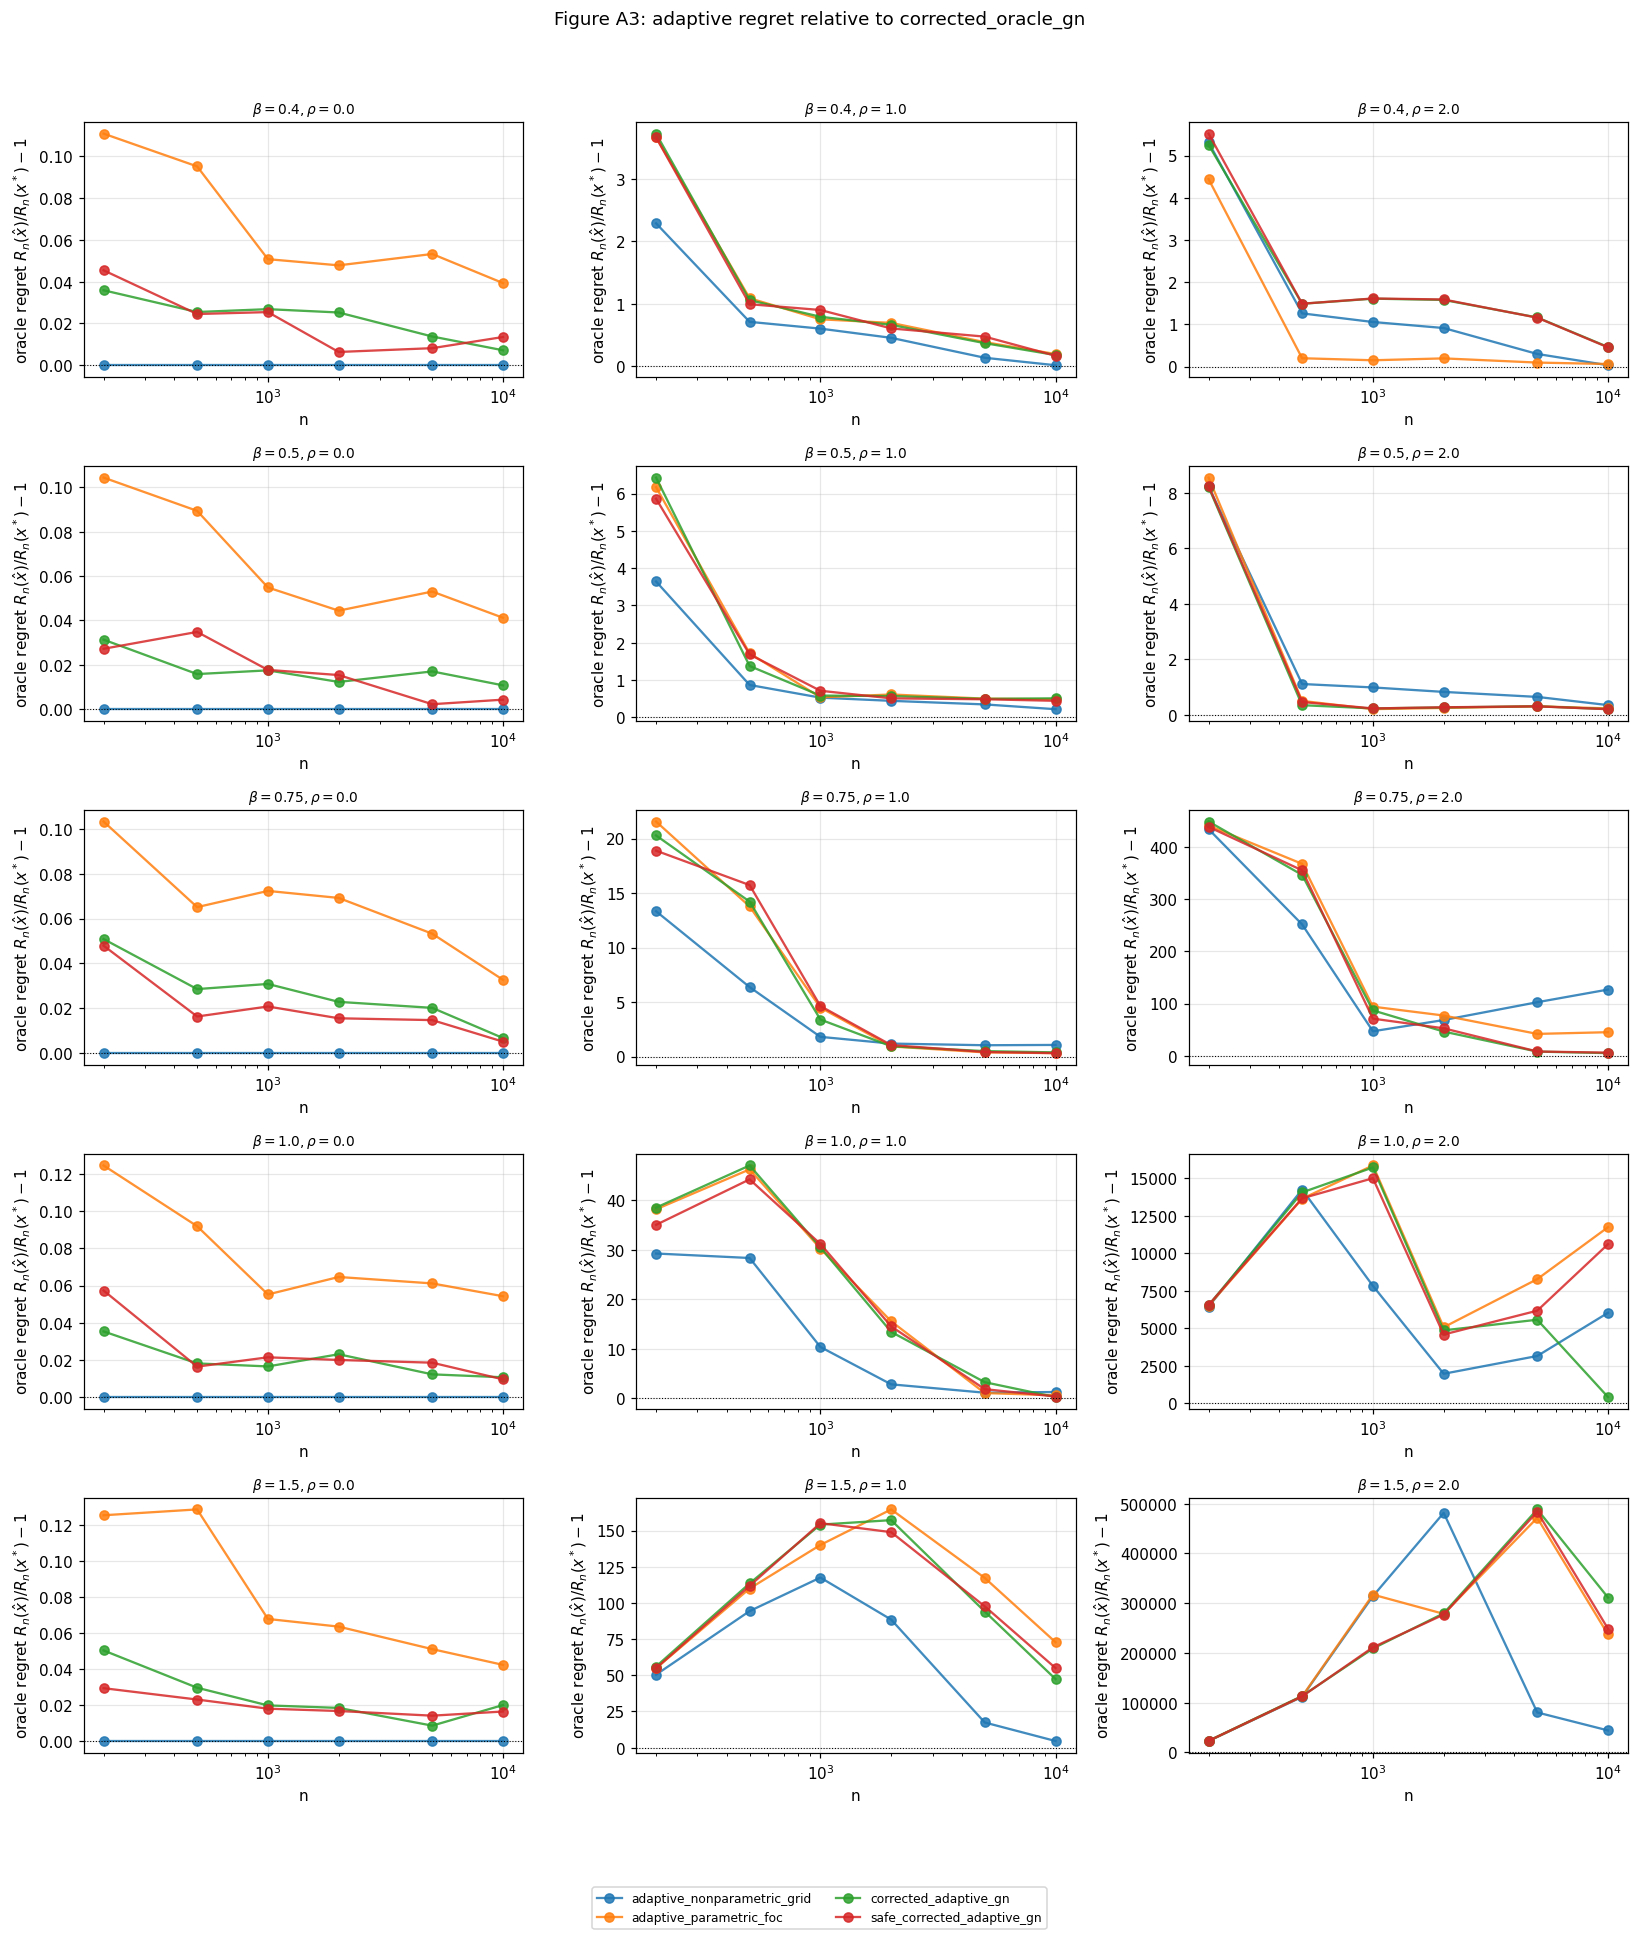

In [15]:
methods_a = ['corrected_adaptive_gn', 'adaptive_parametric_foc',
              'adaptive_nonparametric_grid', 'safe_corrected_adaptive_gn']
sub_a3 = table_a2[table_a2['method'].isin(methods_a)]
pairs = sorted(set(zip(sub_a3['beta'], sub_a3['rho'])))
cols = 3; rows = (len(pairs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.5*rows), squeeze=False)
for ax, (b, r) in zip(axes.flat, pairs):
    cell = sub_a3[(sub_a3['beta']==b) & (sub_a3['rho']==r)]
    for m, mg in cell.groupby('method', observed=True):
        mg = mg.sort_values('n')
        ax.semilogx(mg['n'], mg['oracle_regret'], 'o-', label=m, alpha=0.85)
    ax.axhline(0.0, color='black', linestyle=':', linewidth=0.7)
    ax.set_title(fr'$\beta={b}, \rho={r}$', fontsize=9)
    ax.set_xlabel('n')
    ax.set_ylabel(r'oracle regret $R_n(\hat x)/R_n(x^*) - 1$')
    ax.grid(True, alpha=0.3)
for ax in axes.flat[len(pairs):]:
    ax.axis('off')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Figure A3: adaptive regret relative to corrected_oracle_gn')
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
save_fig(fig, RUN_EXP2, 'figure_a3_adaptive_regret')
plt.show()


#### Table A1 — Learning-curve estimation accuracy


In [16]:
table_a1


,beta,rho,n,method,mean_beta_hat,sd_beta_hat,mean_c_hat,sd_c_hat,n_replications,bias_beta_hat,regime
0,0.4,0.0,200,adaptive_nonparametric_grid,2.305717,2.367372,1734741014515.375244,77577507983341.65625,2000,1.905717,persistent_variance
1,0.4,0.0,200,adaptive_parametric_foc,2.285418,2.372252,2118754654.935462,94294934881.771622,2000,1.885418,persistent_variance
2,0.4,0.0,200,corrected_adaptive_gn,2.333616,2.372726,23128169.958153,1001788968.8432,2000,1.933616,persistent_variance
3,0.4,0.0,200,safe_corrected_adaptive_gn,2.332253,2.366638,26141314161.524197,1167414656761.821533,2000,1.932253,persistent_variance
4,0.4,0.0,500,adaptive_nonparametric_grid,1.80126,2.256646,4187172459.722792,187245760263.547089,2000,1.40126,persistent_variance
...,...,...,...,...,...,...,...,...,...,...,...
355,1.5,2.0,5000,safe_corrected_adaptive_gn,2.417505,2.049782,1032.436003,36142.815217,2000,0.917505,boundary_knife_edge
356,1.5,2.0,10000,adaptive_nonparametric_grid,2.000141,1.662252,121.564829,1251.441198,1000,0.500141,boundary_knife_edge
357,1.5,2.0,10000,adaptive_parametric_foc,2.00074,1.667782,160247.684524,5055598.646707,1000,0.50074,boundary_knife_edge
358,1.5,2.0,10000,corrected_adaptive_gn,1.998989,1.664056,927.465192,13117.42156,1000,0.498989,boundary_knife_edge


#### Table A2 — Adaptive estimator performance


In [17]:
table_a2


,beta,rho,n,method,mse,x_selected,oracle_x,safe_fallback_rate,n_replications,mse_ratio_to_real,oracle_regret,allocation_relative_error,harm_rate,regime
0,0.4,0.0,200,adaptive_nonparametric_grid,0.005197,0.0,0,0.0,2000,1.0,0.0,0.000000,0.0,persistent_variance
1,0.4,0.0,200,adaptive_parametric_foc,0.005773,0.384,0,0.0,2000,1.110828,0.110828,0.384000,1.0,persistent_variance
2,0.4,0.0,200,corrected_adaptive_gn,0.005384,0.1235,0,0.0,2000,1.035876,0.035876,0.123500,1.0,persistent_variance
3,0.4,0.0,200,corrected_oracle_gn,0.005197,0.0,0,0.0,2000,1.0,0.0,0.000000,0.0,persistent_variance
4,0.4,0.0,200,real_only_all,0.005197,0.0,0,0.0,2000,1.0,0.0,0.000000,0.0,persistent_variance
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,1.5,2.0,10000,corrected_adaptive_gn,0.003184,3956.744,10000,0.0,1000,28.461435,311339.243096,0.604326,1.0,boundary_knife_edge
626,1.5,2.0,10000,corrected_oracle_gn,0.0,10000.0,10000,0.0,1000,0.000091,0.0,0.000000,0.0,boundary_knife_edge
627,1.5,2.0,10000,real_only_all,0.000112,0.0,10000,0.0,1000,1.0,10938.021416,1.000000,0.0,boundary_knife_edge
628,1.5,2.0,10000,safe_corrected_adaptive_gn,0.002542,3944.485,10000,0.0,1000,22.721567,248550.71022,0.605551,1.0,boundary_knife_edge


## 3. Experiment 3 — multichannel allocation (§6)


In [18]:
from dataloom.analysis.exp3 import read_run_mc
raw3, oracle3 = read_run_mc(RUN_EXP3 / 'raw')
table_m1 = pd.read_parquet(RUN_EXP3 / 'aggregated' / 'table_m1_multichannel_perf.parquet')
print(f'rows: {len(raw3):,}; table_m1 shape {table_m1.shape}')


rows: 4,800; table_m1 shape (24, 9)


### Figure M1 — Risk surface (representative cell)


In [19]:
from dataloom.multichannel.oracle import R_profile_2
cell = oracle3.sort_values('n', ascending=False).iloc[0]
n = int(cell['n']); b1, b2 = float(cell['beta1']), float(cell['beta2'])
v_n = 1.0 / n
step = max(1, n // 100)
xs = np.arange(1, n, step)
X1, X2 = np.meshgrid(xs, xs, indexing='ij')
feas = (X1 + X2) < n
R = np.full(X1.shape, np.nan)
R[feas] = R_profile_2(X1[feas], X2[feas], n=n, a=1.0, v_n=v_n,
                       c1=1.0, beta1=b1, c2=1.0, beta2=b2)
fig, ax = plt.subplots(figsize=(7, 6))
pcm = ax.pcolormesh(X1, X2, np.log10(R), shading='auto', cmap='viridis')
plt.colorbar(pcm, ax=ax, label=r'$\log_{10} R_n$')
ax.plot(cell['x1_star'], cell['x2_star'], '*', markersize=18,
        color='red', label='corrected oracle')
es = max(1, n // 4)
ax.plot(es, es, 's', markersize=10, color='white', label='equal split')
denom = 1.0 + 2.0 * (b1 + b2)
x1_old = max(1, int(np.floor(n * 2.0 * b1 / denom)))
x2_old = max(1, int(np.floor(n * 2.0 * b2 / denom)))
ax.plot(x1_old, x2_old, '^', markersize=10, color='orange', label='old fixed-share')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.set_title(fr'Figure M1: risk surface (n={n}, $\beta_1$={b1}, $\beta_2$={b2})')
ax.legend(loc='upper right', fontsize=8)
save_fig(fig, RUN_EXP3, 'figure_m1_risk_surface')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/exp3_multichannel__c0dc1ac__20260503T075130__dirty/figures/figure_m1_risk_surface.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/4137123375.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Figure M2 — Marginal-value equality at oracle

Active-channel KKT predicts MV₁ = MV₂ at the corrected oracle.


In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
for (b1, b2), g in oracle3.groupby(['beta1', 'beta2'], observed=True):
    ax.scatter(g['mv1'], g['mv2'], label=fr'$\beta=({b1}, {b2})$',
               alpha=0.7, s=60)
lim = max(oracle3['mv1'].max(), oracle3['mv2'].max())
ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, label='MV1 = MV2')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$MV_1$ at oracle'); ax.set_ylabel(r'$MV_2$ at oracle')
ax.set_title('Figure M2: KKT marginal values at corrected oracle')
ax.legend(fontsize=8)
save_fig(fig, RUN_EXP3, 'figure_m2_marginal_values')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/exp3_multichannel__c0dc1ac__20260503T075130__dirty/figures/figure_m2_marginal_values.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/840669384.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


#### Table M1 — Multichannel performance

In [21]:
table_m1

,beta,rho,n,method,mse,x_total_selected,oracle_total,n_replications,mse_ratio_to_corrected
0,0.4,1.0,500,best_single_channel_oracle,0.002331,75.0,2,200,1.256808
1,0.4,1.0,500,corrected_multichannel_oracle,0.001855,2.0,2,200,1.0
2,0.4,1.0,500,equal_split_two_channels,0.003867,250.0,2,200,2.08481
3,0.4,1.0,500,old_multichannel_fixed_share,0.006731,368.0,2,200,3.628777
4,0.4,1.0,2000,best_single_channel_oracle,0.000575,193.0,2,200,1.070849
5,0.4,1.0,2000,corrected_multichannel_oracle,0.000537,2.0,2,200,1.0
6,0.4,1.0,2000,equal_split_two_channels,0.000789,1000.0,2,200,1.467958
7,0.4,1.0,2000,old_multichannel_fixed_share,0.001709,1473.0,2,200,3.17964
8,0.5,1.0,500,best_single_channel_oracle,0.00217,75.0,2,200,1.088998
9,0.5,1.0,500,corrected_multichannel_oracle,0.001993,2.0,2,200,1.0


## 4. Experiment 4 — inference and coverage (§7)

In [22]:
raw4 = read_run(RUN_EXP4 / 'raw')
table_c1 = pd.read_parquet(RUN_EXP4 / 'aggregated' / 'table_c1_coverage.parquet')
print(f'rows: {len(raw4):,}; table_c1 shape {table_c1.shape}')


rows: 8,400; table_c1 shape (30, 11)


### Figure C1 — Coverage vs n (§7.5)

Per the §16 #7 prediction, `ci_gn_naive` should undercover when
synthetic bias is non-negligible.


In [23]:
ci_methods = ['ci_real_only', 'ci_gn_naive', 'ci_gn_bias_aware',
               'ci_gn_undersmoothed', 'ci_validation_debiased']
sub = table_c1[table_c1['interval_method'].isin(ci_methods)]
pairs = sorted(set(zip(sub['beta'], sub['rho'])))
cols = 2; rows = (len(pairs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), squeeze=False)
for ax, (b, r) in zip(axes.flat, pairs):
    cell = sub[(sub['beta']==b) & (sub['rho']==r)]
    for m, mg in cell.groupby('interval_method', observed=True):
        mg = mg.sort_values('n')
        ax.plot(mg['n'], mg['coverage'], 'o-', label=m, alpha=0.85)
    ax.axhline(0.95, color='black', linestyle=':', linewidth=0.8)
    ax.set_xscale('log'); ax.set_ylim(0, 1.05)
    ax.set_xlabel('n'); ax.set_ylabel('coverage')
    ax.set_title(fr'$\beta={b}, \rho={r}$', fontsize=10)
    ax.grid(True, alpha=0.3)
for ax in axes.flat[len(pairs):]:
    ax.axis('off')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Figure C1: empirical coverage by interval method')
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
save_fig(fig, RUN_EXP4, 'figure_c1_coverage')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/exp4_inference__c0dc1ac__20260503T075132__dirty/figures/figure_c1_coverage.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/3123120416.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Figure C2 — Coverage vs interval length

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
for m, mg in table_c1.groupby('interval_method', observed=True):
    ax.scatter(mg['avg_length'], mg['coverage'], label=m, alpha=0.7, s=40)
ax.axhline(0.95, color='black', linestyle=':', linewidth=0.8)
ax.set_xlabel('average interval length'); ax.set_ylabel('coverage')
ax.set_title('Figure C2: coverage vs interval length')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
save_fig(fig, RUN_EXP4, 'figure_c2_coverage_vs_length')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/exp4_inference__c0dc1ac__20260503T075132__dirty/figures/figure_c2_coverage_vs_length.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/2432217386.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


#### Table C1 — Coverage summary

In [25]:
table_c1

,beta,rho,n,interval_method,coverage,avg_length,median_length,bias,empirical_sd,n_replications,bias_over_se
0,0.5,1.0,500,ci_gn_bias_aware,0.86,0.186962,0.191696,0.025483,0.067338,200,5.35176
1,0.5,1.0,500,ci_gn_naive,0.805,0.169071,0.171029,0.024795,0.070744,200,4.956622
2,0.5,1.0,500,ci_gn_undersmoothed,0.865,0.183542,0.186548,0.021578,0.066403,200,4.595473
3,0.5,1.0,500,ci_real_only,0.925,0.175493,0.17544,-0.003436,0.048395,200,1.00413
4,0.5,1.0,500,ci_validation_debiased,0.94,0.228082,0.201325,0.007712,0.058364,200,1.868604
5,0.5,1.0,2000,ci_gn_bias_aware,0.91,0.096009,0.099178,0.014343,0.023522,200,8.623583
6,0.5,1.0,2000,ci_gn_naive,0.855,0.086038,0.087364,0.011486,0.026005,200,6.246573
7,0.5,1.0,2000,ci_gn_undersmoothed,0.905,0.093391,0.096513,0.010979,0.024955,200,6.221916
8,0.5,1.0,2000,ci_real_only,0.945,0.087612,0.087772,0.00154,0.023237,200,0.937005
9,0.5,1.0,2000,ci_validation_debiased,0.955,0.113184,0.099301,0.009977,0.027415,200,5.146493


## 5. Experiment A — tabular semi-synthetic (§8)

In [26]:
rawA = read_run(RUN_EXPA / 'raw')
table_t2 = pd.read_parquet(RUN_EXPA / 'aggregated' / 'table_t2_tabular_perf.parquet')
print(f'rows: {len(rawA):,}; table_t2 shape {table_t2.shape}')
rawA['estimand'].value_counts()


rows: 4,800; table_t2 shape (78, 14)


estimand
income_mean     2400
subgroup_gap    2400
Name: count, dtype: int64[pyarrow]

### Figure T1 — Empirical learning curve (§8.9)

We don't store per-replication pilot bias points in raw output for tabular,
so this figure summarizes selected x and inferred (β̂, ĉ) per estimand.


In [27]:
sub = rawA[(rawA['method']=='corrected_adaptive_gn') &
            rawA['beta_hat'].notna()]
if not sub.empty:
    fig, axes = plt.subplots(1, sub['estimand'].nunique(),
                              figsize=(5*sub['estimand'].nunique(), 4),
                              squeeze=False)
    for ax, (es, eg) in zip(axes.flat, sub.groupby('estimand', observed=True)):
        agg = (eg.groupby('n')['beta_hat']
                  .agg(['mean','std','count'])
                  .reset_index())
        ax.errorbar(agg['n'], agg['mean'], yerr=agg['std'], fmt='o-')
        ax.set_xscale('log'); ax.set_xlabel('n')
        ax.set_ylabel(r'mean $\hat\beta$')
        ax.set_title(f'estimand={es}')
        ax.grid(True, alpha=0.3)
    fig.suptitle('Figure T1: estimated bias-curve slope across n')
    fig.tight_layout()
    save_fig(fig, RUN_EXPA, 'figure_t1_learning_curve')
    plt.show()
else:
    print('No adaptive bias-fit data in raw — skipping Figure T1.')


wrote /Users/iamsikun/research/dataloom/results/expA_tabular__c0dc1ac__20260503T075135__dirty/figures/figure_t1_learning_curve.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/3161854454.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Figure T2 — Selected x and λ vs n

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for m, mg in rawA[rawA['x_selected'].notna()].groupby('method', observed=True):
    agg = mg.groupby('n')[['x_selected', 'lambda_selected']].mean().reset_index()
    axes[0].semilogx(agg['n'], agg['x_selected'], 'o-', label=m, alpha=0.7)
    axes[1].semilogx(agg['n'], agg['lambda_selected'], 'o-', label=m, alpha=0.7)
axes[0].set_xlabel('n'); axes[0].set_ylabel(r'$\hat x$'); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('n'); axes[1].set_ylabel(r'$\hat\lambda$'); axes[1].grid(alpha=0.3)
axes[0].set_title('Figure T2a: selected x'); axes[1].set_title('Figure T2b: selected λ')
axes[0].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
save_fig(fig, RUN_EXPA, 'figure_t2_selected_allocation')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/expA_tabular__c0dc1ac__20260503T075135__dirty/figures/figure_t2_selected_allocation.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/2350325270.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Figure T3 — MSE ratio to real-only

In [29]:
estimands = sorted(table_t2['estimand'].unique())
fig, axes = plt.subplots(1, len(estimands),
                          figsize=(5*len(estimands), 4),
                          squeeze=False)
for ax, es in zip(axes.flat, estimands):
    eg = table_t2[table_t2['estimand']==es]
    for m, mg in eg.groupby('method', observed=True):
        mg = mg.sort_values('n')
        ax.semilogx(mg['n'], mg['mse_ratio_to_real'], 'o-', label=m, alpha=0.8)
    ax.axhline(1.0, color='black', linestyle=':', linewidth=0.7)
    ax.set_title(f'estimand={es}', fontsize=9)
    ax.set_xlabel('n'); ax.set_ylabel('MSE / MSE(real_only)')
    ax.set_ylim(0, 2.5); ax.grid(True, alpha=0.3)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Figure T3: tabular MSE ratio to real-only')
fig.tight_layout(rect=(0, 0.05, 1, 0.96))
save_fig(fig, RUN_EXPA, 'figure_t3_mse_ratio')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/expA_tabular__c0dc1ac__20260503T075135__dirty/figures/figure_t3_mse_ratio.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/3310212304.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


#### Table T1 — Tabular learning-curve summary

Per-cell (β̂_mean, β̂_sd, R²) for the corrected adaptive method.


In [30]:
if 'beta_hat' in rawA.columns:
    t1 = (rawA[rawA['beta_hat'].notna()]
             .groupby(['dataset','generator','estimand','n','m'])['beta_hat']
             .agg(beta_hat_mean='mean', beta_hat_sd='std', n_reps='count')
             .reset_index())
    t1.to_parquet(RUN_EXPA / 'aggregated' / 'table_t1_tabular_learning.parquet')
    display(t1)


,dataset,generator,estimand,n,m,beta_hat_mean,beta_hat_sd,n_reps
0,adult,bootstrap_smoothed,income_mean,200,200,5.0,0.0,250
1,adult,bootstrap_smoothed,income_mean,200,1000,5.0,0.0,250
2,adult,bootstrap_smoothed,income_mean,500,500,5.0,0.0,250
3,adult,bootstrap_smoothed,income_mean,500,2500,5.0,0.0,250
4,adult,bootstrap_smoothed,income_mean,1000,1000,5.0,0.0,250
5,adult,bootstrap_smoothed,income_mean,1000,5000,5.0,0.0,250
6,adult,bootstrap_smoothed,subgroup_gap,200,200,5.0,0.0,250
7,adult,bootstrap_smoothed,subgroup_gap,200,1000,5.0,0.0,250
8,adult,bootstrap_smoothed,subgroup_gap,500,500,5.0,0.0,250
9,adult,bootstrap_smoothed,subgroup_gap,500,2500,5.0,0.0,250


#### Table T2 — Tabular performance summary

In [31]:
table_t2

,dataset,generator,estimand,n,m,method,bias,variance,mse,x_selected,alpha_selected,fallback_rate,n_replications,mse_ratio_to_real
0,adult,bootstrap_smoothed,income_mean,200,200,corrected_adaptive_gn,-0.012091,0.063218,0.0621,1.0,0.413915,0.0,50,63.730594
1,adult,bootstrap_smoothed,income_mean,200,200,fixed_half_split_plugin_alpha,-0.002798,0.001643,0.001618,100.0,0.217346,0.0,50,1.660747
2,adult,bootstrap_smoothed,income_mean,200,200,naive_pooling,-0.001922,0.001382,0.001358,100.0,0.333333,0.0,50,1.393236
3,adult,bootstrap_smoothed,income_mean,200,200,old_fixed_share_plugin_alpha,-0.005108,0.002078,0.002062,145.0,0.069883,0.0,50,2.116289
4,adult,bootstrap_smoothed,income_mean,200,200,real_only_all,-0.001822,0.000991,0.000974,0.0,1.0,0.0,50,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,adult,bootstrap_smoothed,subgroup_gap,1000,5000,fixed_half_split_plugin_alpha,0.001218,0.000983,0.000965,500.0,0.052633,0.0,50,2.11222
74,adult,bootstrap_smoothed,subgroup_gap,1000,5000,naive_pooling,0.001015,0.000611,0.0006,500.0,0.090909,0.0,50,1.314473
75,adult,bootstrap_smoothed,subgroup_gap,1000,5000,old_fixed_share_plugin_alpha,0.001439,0.000729,0.000716,727.0,0.013361,0.0,50,1.568684
76,adult,bootstrap_smoothed,subgroup_gap,1000,5000,real_only_all,-0.000805,0.000465,0.000457,0.0,1.0,0.0,50,1.0


## 6. Experiment B — causal digital-twin (§9)

In [32]:
rawB = read_run(RUN_EXPB / 'raw')
table_d1 = pd.read_parquet(RUN_EXPB / 'aggregated' / 'table_d1_causal_perf.parquet')
print(f'rows: {len(rawB):,}; table_d1 shape {table_d1.shape}')


rows: 2,700; table_d1 shape (54, 14)


### Figure D1 — Causal learning curve (per-method β̂ across n)

In [33]:
subB = rawB[(rawB['method'].str.contains('adaptive', na=False)) &
             rawB['beta_hat'].notna()]
if not subB.empty:
    fig, ax = plt.subplots(figsize=(7, 5))
    for m, mg in subB.groupby('method', observed=True):
        agg = mg.groupby('n')['beta_hat'].agg(['mean','std']).reset_index()
        ax.errorbar(agg['n'], agg['mean'], yerr=agg['std'],
                    fmt='o-', label=m, alpha=0.8)
    ax.set_xscale('log'); ax.set_xlabel('n')
    ax.set_ylabel(r'mean $\hat\beta$ (causal bias-curve)')
    ax.set_title('Figure D1: causal bias-curve estimate across n')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    save_fig(fig, RUN_EXPB, 'figure_d1_causal_learning_curve')
    plt.show()
else:
    print('No adaptive β̂ data in raw — skipping Figure D1.')


wrote /Users/iamsikun/research/dataloom/results/expB_causal__c0dc1ac__20260503T075151__dirty/figures/figure_d1_causal_learning_curve.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/2182022435.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Figure D2 — ATE MSE ratio

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
for m, mg in table_d1.groupby('method', observed=True):
    mg = mg.sort_values('n')
    ax.semilogx(mg['n'], mg['mse_ratio_to_real'], 'o-', label=m, alpha=0.8)
ax.axhline(1.0, color='black', linestyle=':', linewidth=0.7)
ax.set_xlabel('n'); ax.set_ylabel('ATE MSE / ATE MSE(real-only baseline)')
ax.set_title('Figure D2: ATE MSE ratio (causal)')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax.grid(True, alpha=0.3)
save_fig(fig, RUN_EXPB, 'figure_d2_ate_mse_ratio')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/expB_causal__c0dc1ac__20260503T075151__dirty/figures/figure_d2_ate_mse_ratio.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/833590910.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Figure D3 — Coverage vs interval length (causal)

The causal smoke run does not include CI columns yet (the runner emits
point estimates only). When interval methods are added to Exp B, this
cell will populate; for now we render a placeholder + note.


In [35]:
if 'ci_lower' in rawB.columns and rawB['ci_lower'].notna().any():
    sub = rawB.dropna(subset=['ci_lower','ci_upper'])
    sub['length'] = sub['ci_upper'] - sub['ci_lower']
    sub['covered'] = (sub['ci_lower'] <= sub['theta_true']) & \
                       (sub['theta_true'] <= sub['ci_upper'])
    s = sub.groupby('method').agg(coverage=('covered','mean'),
                                     avg_length=('length','mean')).reset_index()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(s['avg_length'], s['coverage'], s=80)
    for _, row in s.iterrows():
        ax.annotate(row['method'], (row['avg_length'], row['coverage']),
                    fontsize=7, xytext=(4,4), textcoords='offset points')
    ax.axhline(0.95, color='black', linestyle=':', linewidth=0.7)
    ax.set_xlabel('avg interval length'); ax.set_ylabel('coverage')
    ax.set_title('Figure D3: coverage vs interval length (causal)')
    save_fig(fig, RUN_EXPB, 'figure_d3_coverage_vs_length')
    plt.show()
else:
    print('Causal runner does not yet emit CI columns — Figure D3 skipped.')
    print('To enable: extend semisynth/causal_runner._run_one to call ci_*\n'
          'methods alongside the point estimators.')


Causal runner does not yet emit CI columns — Figure D3 skipped.
To enable: extend semisynth/causal_runner._run_one to call ci_*
methods alongside the point estimators.


#### Table D1 — Causal performance summary

In [36]:
table_d1

,dataset,generator,estimand,n,m,method,bias,variance,mse,x_selected,alpha_selected,fallback_rate,n_replications,mse_ratio_to_real
0,ihdp_synthetic,linear_outcome_model,ate,200,200,corrected_adaptive_gn,0.001839,0.112924,0.108584,27.730769,0.743668,0.0,26,4.703612
1,ihdp_synthetic,linear_outcome_model,ate,200,200,fixed_half_split_plugin_alpha,-0.030766,0.065526,0.065016,100.0,0.641089,0.0,45,2.816344
2,ihdp_synthetic,linear_outcome_model,ate,200,200,naive_pooling,-0.094164,0.036692,0.044825,100.0,0.333333,0.0,50,1.941716
3,ihdp_synthetic,linear_outcome_model,ate,200,200,old_fixed_share_plugin_alpha,-0.012624,0.041344,0.040288,83.058824,0.559439,0.0,34,1.745169
4,ihdp_synthetic,linear_outcome_model,ate,200,200,real_only_aipw,-0.069892,0.018572,0.023085,0.0,1.0,0.0,50,1.0
5,ihdp_synthetic,linear_outcome_model,ate,200,200,real_only_diff_in_means,0.116163,0.019994,0.033088,0.0,1.0,0.0,50,1.433302
6,ihdp_synthetic,linear_outcome_model,ate,200,200,safe_corrected_adaptive_gn,-0.088339,0.120881,0.124367,20.035714,0.775793,0.428571,28,5.38729
7,ihdp_synthetic,linear_outcome_model,ate,200,200,synthetic_only_full_calibration,-0.070156,0.031022,0.035323,200.0,0.0,0.0,50,1.530123
8,ihdp_synthetic,linear_outcome_model,ate,200,200,validation_debiased_gn,-0.083824,0.03871,0.044248,27.461538,0.716807,0.0,26,1.916703
9,ihdp_synthetic,linear_outcome_model,ate,200,1000,corrected_adaptive_gn,-0.030826,0.057591,0.056555,49.689655,0.575593,0.0,29,2.134532


## 7. Master figures and tables for the paper (§12, §13)

Distilled headline plots/tables for the NeurIPS submission.


### Main Figure 1 — Theoretical phase diagram (with regions)


In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
betas_fine = np.linspace(0.1, 2.5, 400)
rhos_fine = np.linspace(0.0, 3.5, 400)
BB, RR = np.meshgrid(betas_fine, rhos_fine, indexing='ij')
regime_idx = np.zeros_like(BB)
name_to_idx = {k: i for i, k in enumerate(REGIME_COLORS)}
for i, b in enumerate(betas_fine):
    for j, r in enumerate(rhos_fine):
        regime_idx[i, j] = name_to_idx[classify_regime(b, r)]
from matplotlib.colors import ListedColormap
cmap = ListedColormap([REGIME_COLORS[k] for k in REGIME_COLORS])
pcm = ax.pcolormesh(BB, RR, regime_idx, cmap=cmap, shading='auto', alpha=0.8)
ax.axhline(1.0, color='black', linestyle=':', linewidth=1.0,
           label=r'$\rho=1$ (common case)')
for b in betas:
    for r in rhos:
        ax.scatter(b, r, marker='o', edgecolor='white', facecolor='black',
                    s=20, zorder=3)
handles = [plt.Line2D([0],[0], marker='s', color='w',
                       markerfacecolor=c, markersize=14, label=k)
           for k, c in REGIME_COLORS.items()]
handles.append(plt.Line2D([0], [0], color='black', linestyle=':',
                            label=r'$\rho=1$'))
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=8, frameon=False)
ax.set_xlabel(r'$\beta$'); ax.set_ylabel(r'$\rho$')
ax.set_title('Main Figure 1: phase diagram (regions filled, simulated cells dotted)')
save_fig(fig, RUN_EXP1, 'main_figure_1_phase_diagram')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/exp1_phase_diagram__c0dc1ac__20260503T074341__dirty/figures/main_figure_1_phase_diagram.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/2346276666.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Main Figure 2 — Synthetic scaling validation

In [38]:
interior_pairs = [(b, r) for b in betas for r in rhos
                   if classify_regime(b, r) == 'sublinear_fast_learning']
fig, ax = plt.subplots(figsize=(8, 6))
for b, r in sorted(interior_pairs):
    sub = cell_oracle[(cell_oracle['beta']==b) & (cell_oracle['rho']==r)]
    sub = sub[sub['oracle_x'] > 0].sort_values('n')
    if sub.empty:
        continue
    sl = theory_slope(b, r)
    n_arr = sub['n'].to_numpy(dtype=float)
    ref = sub['oracle_x'].iloc[0] / (n_arr[0] ** sl)
    line, = ax.loglog(n_arr, sub['oracle_x'], 'o-', alpha=0.7,
                       label=fr'$\beta={b}, \rho={r}$ (slope {sl:.2f})')
    ax.loglog(n_arr, ref * n_arr ** sl, '--', alpha=0.5,
               color=line.get_color())
ax.set_xlabel('n'); ax.set_ylabel(r'oracle $x_n^*$')
ax.set_title('Main Figure 2: empirical $x_n^*$ vs theoretical scaling (interior fast-learning regime)')
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=False)
ax.grid(True, which='both', alpha=0.3)
save_fig(fig, RUN_EXP1, 'main_figure_2_scaling_validation')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/exp1_phase_diagram__c0dc1ac__20260503T074341__dirty/figures/main_figure_2_scaling_validation.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/2873933627.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Main Figure 3 — MSE ratio comparison (representative regimes)

Real-only, old fixed-share, corrected oracle, corrected adaptive, safe adaptive.


In [39]:
main3_methods = ['real_only_all', 'old_fixed_share_oracle_alpha',
                  'corrected_oracle_gn',
                  'corrected_adaptive_gn', 'safe_corrected_adaptive_gn']
rep_pairs = [(0.5, 1.0), (1.0, 1.0), (1.5, 1.0)]
fig, axes = plt.subplots(1, len(rep_pairs),
                          figsize=(5*len(rep_pairs), 4), squeeze=False)
for ax, (b, r) in zip(axes.flat, rep_pairs):
    s1_perf = table_s2[(table_s2['beta']==b) & (table_s2['rho']==r) &
                        table_s2['estimator'].isin(main3_methods)]
    s2_perf = table_a2[(table_a2['beta']==b) & (table_a2['rho']==r) &
                        table_a2['method'].isin(main3_methods)]
    for est, eg in s1_perf.groupby('estimator', observed=True):
        eg = eg.sort_values('n')
        ax.semilogx(eg['n'], eg['mse_ratio_to_real'], 'o-', label=est, alpha=0.85)
    for m, mg in s2_perf.groupby('method', observed=True):
        if m in s1_perf['estimator'].unique():
            continue
        mg = mg.sort_values('n')
        ax.semilogx(mg['n'], mg['mse_ratio_to_real'], 's--', label=m, alpha=0.85)
    ax.axhline(1.0, color='black', linestyle=':', linewidth=0.7)
    ax.set_xlabel('n'); ax.set_ylabel('MSE / MSE(real-only)')
    ax.set_title(fr'$\beta={b}, \rho={r}$', fontsize=10)
    ax.set_ylim(0, 1.5); ax.grid(True, alpha=0.3)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Main Figure 3: MSE ratio across estimators')
fig.tight_layout(rect=(0, 0.04, 1, 0.96))
save_fig(fig, RUN_EXP1, 'main_figure_3_mse_comparison')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/exp1_phase_diagram__c0dc1ac__20260503T074341__dirty/figures/main_figure_3_mse_comparison.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/2465652062.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Main Figure 4 — Semi-synthetic result

Tabular learning curve + MSE ratios (Exp A); causal alternative below.


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# left: T1-style learning curve
if 'beta_hat' in rawA.columns:
    sub = rawA[rawA['beta_hat'].notna()]
    for es, eg in sub.groupby('estimand', observed=True):
        agg = eg.groupby('n')['beta_hat'].agg(['mean','std']).reset_index()
        axes[0].errorbar(agg['n'], agg['mean'], yerr=agg['std'], fmt='o-',
                          label=es, alpha=0.85)
    axes[0].set_xscale('log'); axes[0].set_xlabel('n')
    axes[0].set_ylabel(r'mean $\hat\beta$')
    axes[0].set_title('learning-curve slope across n')
    axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
# right: MSE ratio per method (income_mean estimand)
ax = axes[1]
ig = table_t2[table_t2['estimand']=='income_mean']
for m, mg in ig.groupby('method', observed=True):
    mg = mg.sort_values('n')
    ax.semilogx(mg['n'], mg['mse_ratio_to_real'], 'o-', label=m, alpha=0.85)
ax.axhline(1.0, color='black', linestyle=':', linewidth=0.7)
ax.set_xlabel('n'); ax.set_ylabel('MSE / MSE(real-only)')
ax.set_title('MSE ratio (income_mean estimand)')
ax.set_ylim(0, 2.0); ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.suptitle('Main Figure 4: tabular semi-synthetic result')
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_fig(fig, RUN_EXPA, 'main_figure_4_semisynth')
plt.show()


wrote /Users/iamsikun/research/dataloom/results/expA_tabular__c0dc1ac__20260503T075135__dirty/figures/main_figure_4_semisynth.pdf + .png


/var/folders/3l/3v_7k8t579j60k6cv9rj77080000gn/T/ipykernel_89699/1318048249.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Main Table 1 — Phase diagram validation

In [41]:
old_lambda = (lambda b: (2.0 * b) / (1.0 + 2.0 * b))
rows_main1 = []
for _, row in ts1.iterrows():
    b, r = row['beta'], row['rho']
    rows_main1.append({
        'beta': b, 'rho': r,
        'predicted_regime': row['theory_regime'],
        'predicted_slope': row['theory_slope'],
        'empirical_slope': row['empirical_slope'],
        'corrected_lambda_at_largest_n': row['mean_oracle_lambda_at_largest_n'],
        'old_fixed_share_lambda': old_lambda(b),
    })
main_table_1 = pd.DataFrame(rows_main1)
main_table_1.to_parquet(RUN_EXP1 / 'aggregated' / 'main_table_1_phase_diagram.parquet')
main_table_1


,beta,rho,predicted_regime,predicted_slope,empirical_slope,corrected_lambda_at_largest_n,old_fixed_share_lambda
0,0.25,0.0,persistent_variance,0.000000,NaN,0.00000,0.333333
1,0.25,0.5,slow_learning,0.000000,NaN,0.00000,0.333333
2,0.25,1.0,slow_learning,0.000000,NaN,0.00000,0.333333
3,0.25,1.5,slow_learning,0.000000,NaN,0.00000,0.333333
4,0.25,2.0,slow_learning,0.000000,NaN,0.00000,0.333333
5,0.25,3.0,slow_learning,0.000000,NaN,0.00005,0.333333
6,0.40,0.0,persistent_variance,0.000000,NaN,0.00000,0.444444
7,0.40,0.5,slow_learning,0.000000,NaN,0.00000,0.444444
8,0.40,1.0,slow_learning,0.000000,NaN,0.00000,0.444444
9,0.40,1.5,slow_learning,0.000000,NaN,0.00000,0.444444


### Main Table 2 — Estimator performance (representative regimes)

In [42]:
rep_cells_2 = [(0.5, 1.0), (1.0, 1.0), (1.5, 1.0), (1.0, 0.0), (1.0, 2.0)]
main_table_2 = []
for b, r in rep_cells_2:
    sub = table_s2[(table_s2['beta']==b) & (table_s2['rho']==r)]
    if sub.empty:
        continue
    nmax = sub['n'].max()
    sub_n = sub[sub['n']==nmax]
    for _, row in sub_n.iterrows():
        main_table_2.append({
            'regime': classify_regime(b, r),
            'beta': b, 'rho': r, 'n': nmax,
            'estimator': row['estimator'],
            'x_selected': row['x_selected'],
            'lambda_selected': row['lambda_selected'],
            'alpha_selected': row['alpha_selected'],
            'bias': row['bias'],
            'variance': row['variance'],
            'mse': row['mse'],
            'mse_ratio_to_real': row['mse_ratio_to_real'],
            'oracle_regret': row['oracle_regret'],
        })
main_table_2 = pd.DataFrame(main_table_2)
main_table_2.to_parquet(RUN_EXP1 / 'aggregated' / 'main_table_2_estimator_perf.parquet')
main_table_2


,regime,beta,rho,n,estimator,x_selected,lambda_selected,alpha_selected,bias,variance,mse,mse_ratio_to_real,oracle_regret
0,parametric_knife_edge,0.5,1.0,20000,corrected_oracle_gn,0.0,0.00000,1.000000,0.000176,5.130703e-05,5.131221e-05,1.000000,0.000000
1,parametric_knife_edge,0.5,1.0,20000,fixed_half_split_oracle_alpha,10000.0,0.50000,0.600000,0.004207,4.331585e-05,6.099513e-05,1.188706,0.188706
2,parametric_knife_edge,0.5,1.0,20000,naive_pooling,10000.0,0.50000,0.999900,0.000360,1.025229e-04,1.026013e-04,1.999548,0.999548
3,parametric_knife_edge,0.5,1.0,20000,old_fixed_share_oracle_alpha,10000.0,0.50000,0.600000,0.003916,4.360672e-05,5.891765e-05,1.148219,0.148219
4,parametric_knife_edge,0.5,1.0,20000,real_only_all,0.0,0.00000,1.000000,0.000176,5.130703e-05,5.131221e-05,1.000000,0.000000
5,parametric_knife_edge,0.5,1.0,20000,safe_corrected_oracle_gn,0.0,0.00000,1.000000,0.000176,5.130703e-05,5.131221e-05,1.000000,0.000000
6,parametric_knife_edge,0.5,1.0,20000,synthetic_only_full_calibration,20000.0,1.00000,0.000000,0.006910,5.102081e-05,9.874711e-05,1.924437,0.924437
7,sublinear_fast_learning,1.0,1.0,20000,corrected_oracle_gn,914.0,0.04570,0.494221,0.000700,2.534283e-05,2.582070e-05,0.534786,0.000000
8,sublinear_fast_learning,1.0,1.0,20000,fixed_half_split_oracle_alpha,10000.0,0.50000,0.333378,0.000295,3.422279e-05,3.429241e-05,0.710249,0.328098
9,sublinear_fast_learning,1.0,1.0,20000,naive_pooling,10000.0,0.50000,0.999900,0.000483,9.904293e-05,9.922642e-05,2.055132,2.842903


### Main Table 3 — Semi-synthetic performance

In [43]:
tt2 = table_t2.copy()
tt2['lambda_selected'] = tt2['x_selected'] / tt2['n']
tt2['coverage'] = np.nan  # tabular runner does not emit CIs
main_table_3 = tt2[['dataset','generator','estimand','method','n','m',
                     'x_selected','lambda_selected','mse_ratio_to_real',
                     'fallback_rate']]
main_table_3.to_parquet(RUN_EXPA / 'aggregated' / 'main_table_3_semisynth.parquet')
main_table_3


,dataset,generator,estimand,method,n,m,x_selected,lambda_selected,mse_ratio_to_real,fallback_rate
0,adult,bootstrap_smoothed,income_mean,corrected_adaptive_gn,200,200,1.0,0.005,63.730594,0.0
1,adult,bootstrap_smoothed,income_mean,fixed_half_split_plugin_alpha,200,200,100.0,0.5,1.660747,0.0
2,adult,bootstrap_smoothed,income_mean,naive_pooling,200,200,100.0,0.5,1.393236,0.0
3,adult,bootstrap_smoothed,income_mean,old_fixed_share_plugin_alpha,200,200,145.0,0.725,2.116289,0.0
4,adult,bootstrap_smoothed,income_mean,real_only_all,200,200,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
73,adult,bootstrap_smoothed,subgroup_gap,fixed_half_split_plugin_alpha,1000,5000,500.0,0.5,2.11222,0.0
74,adult,bootstrap_smoothed,subgroup_gap,naive_pooling,1000,5000,500.0,0.5,1.314473,0.0
75,adult,bootstrap_smoothed,subgroup_gap,old_fixed_share_plugin_alpha,1000,5000,727.0,0.727,1.568684,0.0
76,adult,bootstrap_smoothed,subgroup_gap,real_only_all,1000,5000,0.0,0.0,1.0,0.0


## 8. Discrepancy summary

Where empirical results diverge from theory predictions, list them here.
Per §16 of `docs/experiments.md`: do **not** smooth or hide.


In [44]:
discrepancies = []
# (a) Slope disagreements from Table S1
for _, row in ts1.iterrows():
    if row.get('flag') == '(disagrees with theory)':
        discrepancies.append(
            f"S1 (β={row['beta']}, ρ={row['rho']}): theory slope "
            f"{row['theory_slope']:.3f}, empirical {row['empirical_slope']:.3f} "
            f"(SE {row['slope_se']:.3f})")
# (b) Adaptive harm at large n
if not table_a2.empty:
    harmful = table_a2[(table_a2['mse_ratio_to_real'] > 1.05) &
                        (table_a2['method'].str.contains('adaptive'))]
    for _, row in harmful.iterrows():
        discrepancies.append(
            f"A2 ({row['method']}, β={row['beta']}, ρ={row['rho']}, n={row['n']}): "
            f"MSE ratio {row['mse_ratio_to_real']:.3f} > 1 (synthetic data is harmful)")
# (c) Coverage failures — expected for ci_gn_naive but report if it covers >0.95
if not table_c1.empty:
    over = table_c1[(table_c1['interval_method']=='ci_gn_naive') &
                      (table_c1['coverage'] >= 0.94)]
    for _, row in over.iterrows():
        discrepancies.append(
            f"C1 (β={row['beta']}, n={row['n']}): ci_gn_naive coverage "
            f"{row['coverage']:.3f} >= 0.94 (theory predicts undercoverage)")
if discrepancies:
    print(f'{len(discrepancies)} discrepancy(ies) detected:')
    for d in discrepancies:
        print('  -', d)
else:
    print('No theory-empirical discrepancies above the flag thresholds.')


253 discrepancy(ies) detected:
  - S1 (β=0.75, ρ=0.5): theory slope 0.400, empirical 0.453 (SE 0.006)
  - S1 (β=0.75, ρ=1.0): theory slope 0.800, empirical 0.842 (SE 0.003)
  - S1 (β=1.0, ρ=0.5): theory slope 0.333, empirical 0.375 (SE 0.011)
  - S1 (β=1.0, ρ=1.0): theory slope 0.667, empirical 0.684 (SE 0.003)
  - A2 (adaptive_parametric_foc, β=0.4, ρ=0.0, n=200): MSE ratio 1.111 > 1 (synthetic data is harmful)
  - A2 (adaptive_parametric_foc, β=0.4, ρ=0.0, n=500): MSE ratio 1.095 > 1 (synthetic data is harmful)
  - A2 (adaptive_parametric_foc, β=0.4, ρ=0.0, n=1000): MSE ratio 1.051 > 1 (synthetic data is harmful)
  - A2 (adaptive_parametric_foc, β=0.4, ρ=0.0, n=5000): MSE ratio 1.053 > 1 (synthetic data is harmful)
  - A2 (adaptive_nonparametric_grid, β=0.4, ρ=1.0, n=200): MSE ratio 3.290 > 1 (synthetic data is harmful)
  - A2 (adaptive_parametric_foc, β=0.4, ρ=1.0, n=200): MSE ratio 4.667 > 1 (synthetic data is harmful)
  - A2 (corrected_adaptive_gn, β=0.4, ρ=1.0, n=200): MSE ratio 